# Epileptic Seizure Prediction from EEG Signals
## Modelling Pre-Ictal Temporal Dynamics for Cross-Patient Generalization
**Gonçalo Filipe de Brito Pacheco — NOVA IMS**

---

### Pipeline overview
```
CHB-MIT EDF files
    │
    ▼
[1] Parse summary files  →  seizure-containing EDF list + timestamps
    │
    ▼
[2] Load EDF  →  18 canonical bipolar channels @ 256 Hz
    │
    ▼
[3] Band-pass filter 0.5–30 Hz  (zero-phase Butterworth, order 4)
    │
    ▼
[4] Segment  →  20-second windows, 50 % overlap
    │
    ▼
[5] Label  →  preictal [−30 min, −5 min], interictal, excluded
    │
    ▼
[6] Granger Causality  →  18×18 directed connectivity matrix / window
    │
    ▼
[7] CNN  (2-D conv on 18×18 matrix)  →  P(preictal)
    │
    ▼
[8] LOPO cross-validation  +  Pooled baseline
    │
    ▼
[9] Metrics: AUC, Sensitivity, Specificity, F1, FPR/h
```

## 0 · Setup

In [ ]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project folder to path
PROJECT_DIR = Path(".")   
# sys.path.insert(0, str(PROJECT_DIR))

from config import (
    DATA_ROOT, EXCLUDED_PATIENTS, CANONICAL_CHANNELS,
    GC_MATRICES_DIR, RESULTS_DIR,
    WINDOW_SEC, OVERLAP, PREICTAL_SEC, SPH_SEC,
)
from summary_parser import parse_all_summaries
from data_loader    import load_edf
from preprocessing  import preprocess_file, print_label_stats
from granger        import process_file_to_gc
from model          import GCPredictor
from train_evaluate import run_lopo, run_pooled, save_results
from metrics        import print_metrics

print("All imports OK.")
print(f"Data root: {DATA_ROOT}")

All imports OK.
Data root: <repo>/physionet


---
## 1 · Parse Summary Files
Extract seizure onset / offset times and identify seizure-containing EDF files.

In [2]:
all_seizures = parse_all_summaries(DATA_ROOT, EXCLUDED_PATIENTS)

print(f"\nPatients retained : {len(all_seizures)}")
total_files    = sum(len(v) for v in all_seizures.values())
total_seizures = sum(len(sz) for v in all_seizures.values() for sz in v.values())
print(f"Seizure EDF files : {total_files}")
print(f"Total seizures    : {total_seizures}")

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] Skipping excluded patient: chb12
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total seizures
[INFO] chb1

---
## 2–6 · Feature Extraction Pipeline
For each patient → each seizure-containing EDF file:
1. Load 18 canonical channels
2. Band-pass filter
3. Segment into 20-second windows
4. Label (preictal / interictal / excluded)
5. Compute 18×18 Granger causality matrix per window

> **Cache note:** GC matrices are saved to `gc_matrices/` on first run.
> Subsequent runs load from cache — much faster.

In [ ]:
patient_data = {}

for patient_id, seizure_map in all_seizures.items():
    patient_dir = Path(DATA_ROOT) / patient_id
    patient_gc_list = []
    patient_lb_list = []

    print(f"\n{'─'*55}")
    print(f"Patient: {patient_id}  ({len(seizure_map)} seizure-containing files)")

    for edf_name, seizures in seizure_map.items():
        edf_path = patient_dir / edf_name

        # ── Load ────────────────────────────────────────────────────────
        try:
            data, fs = load_edf(str(edf_path))
        except Exception as e:
            print(f"  [SKIP] {edf_name}: {e}")
            continue

        # ── Filter + Segment + Label ─────────────────────────────────────
        windows, labels, start_times = preprocess_file(data, seizures, fs)
        print_label_stats(labels, patient_id, edf_name)

        if len(labels) == 0 or (labels == 1).sum() == 0:
            print(f"  [SKIP] {edf_name}: no usable preictal windows.")
            continue

        # ── Granger Causality ─────────────────────────────────────────────
        gc_matrices, labels_gc = process_file_to_gc(
            windows, labels,
            patient_id=patient_id,
            fname=edf_name,
            use_cache=True,
            verbose=True,
        )

        patient_gc_list.append(gc_matrices)
        patient_lb_list.append(labels_gc)

    if not patient_gc_list:
        print(f"  [SKIP] {patient_id}: no valid data after processing.")
        continue

    gc_all  = np.concatenate(patient_gc_list, axis=0)
    lab_all = np.concatenate(patient_lb_list, axis=0)
    patient_data[patient_id] = (gc_all, lab_all)

    print(f"  {patient_id}: {gc_all.shape[0]} windows  "
          f"preictal={(lab_all==1).sum()}  interictal={(lab_all==0).sum()}")

print(f"\n{'='*55}")
print(f"Feature extraction complete. Patients with data: {len(patient_data)}")


───────────────────────────────────────────────────────
Patient: chb01  (7 seizure-containing files)


<repo>/Code/data_loader.py:93: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[chb01/chb01_03.edf]  preictal= 148  interictal=  146  ratio=1:0
  [GC] Cache hit: chb01/chb01_03.edf


<repo>/Code/data_loader.py:93: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


    [LABEL] Seizure at 1467s: preictal window out of bounds (would start at -333s) — skipping preictal label.
[chb01/chb01_04.edf]  preictal=   0  interictal=  174  ratio=1:174
  [SKIP] chb01_04.edf: no usable preictal windows.


...

[chb24/chb24_15.edf]  preictal= 148  interictal=  202  ratio=1:1
  [GC] Cache hit: chb24/chb24_15.edf


<repo>/Code/data_loader.py:93: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[chb24/chb24_17.edf]  preictal= 148  interictal=  198  ratio=1:1
  [GC] Cache hit: chb24/chb24_17.edf


<repo>/Code/data_loader.py:93: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


[chb24/chb24_21.edf]  preictal= 148  interictal=  127  ratio=1:0
  [GC] Cache hit: chb24/chb24_21.edf
  ✓ chb24: 1930 windows  preictal=939  interictal=991

Feature extraction complete. Patients with data: 23


---
## 7 · Dataset Summary

In [4]:
summary_rows = []
for pid, (gc, lb) in patient_data.items():
    summary_rows.append({
        "patient":     pid,
        "n_total":     len(lb),
        "n_preictal":  (lb == 1).sum(),
        "n_interictal":(lb == 0).sum(),
        "ratio":       round((lb == 0).sum() / max((lb == 1).sum(), 1), 1),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f"\nTotal windows : {summary_df['n_total'].sum()}")
print(f"Overall ratio  : 1:{summary_df['n_interictal'].sum() // summary_df['n_preictal'].sum()}")

patient  n_total  n_preictal  n_interictal  ratio
  chb01      475         296           179    0.6
  chb02      623         296           327    1.1
  chb03      658         444           214    0.5
  chb04     2017         296          1721    5.8
  chb05      695         444           251    0.6
  chb06     6461        1037          5424    5.2
  chb07     2933         445          2488    5.6
  chb08     1276         741           535    0.7
  chb09     2823         592          2231    3.8
  chb10     3418         888          2530    2.8
  chb11      264         148           116    0.8
  chb13      772         444           328    0.7
  chb14     1287         774           513    0.7
  chb15      594         320           274    0.9
  chb16      465         347           118    0.3
  chb17      828         444           384    0.9
  chb18      944         592           352    0.6
  chb19      601         296           305    1.0
  chb20      550         369           181    0.5


---
## 8 · LOPO Cross-Validation (Primary Evaluation)

In [5]:
lopo_results = run_lopo(patient_data, val_fraction=0.15, verbose=True)


LOPO cross-validation  (23 folds)  |  device: cpu

[Fold 1/23]  Test patient: chb01
  Train: 27600 windows  (preictal=9585, interictal=18015)
  Val  : 4870 windows
  Test : 475 windows  (preictal=296, interictal=179)
    Epoch   5/50  train_loss=0.6895  val_loss=0.6790
    Epoch  10/50  train_loss=0.5818  val_loss=0.5845
    Epoch  15/50  train_loss=0.4936  val_loss=0.5399
    Epoch  20/50  train_loss=0.4242  val_loss=0.5169
    Epoch  25/50  train_loss=0.3690  val_loss=0.5214
    Epoch  30/50  train_loss=0.3291  val_loss=0.4721
    Epoch  35/50  train_loss=0.2873  val_loss=0.5006
    Epoch  40/50  train_loss=0.2625  val_loss=0.5034
    Epoch  45/50  train_loss=0.2355  val_loss=0.4829
    Epoch  50/50  train_loss=0.2107  val_loss=0.4917
  → AUC=0.683  Sens=0.132  Spec=0.972  F1=0.229

[Fold 2/23]  Test patient: chb02
  Train: 27474 windows  (preictal=9586, interictal=17888)
  Val  : 4848 windows
  Test : 623 windows  (preictal=296, interictal=327)
    Epoch   5/50  train_loss=0.6929  

---
## 9 · Pooled Baseline (Reference)

In [6]:
pooled_results = run_pooled(patient_data, test_fraction=0.20, val_fraction=0.15, verbose=True)


Pooled evaluation  |  device: cpu
  Train: 22403  Val: 3953  Test: 6589
    Epoch   5/50  train_loss=0.6996  val_loss=0.7805
    Epoch  10/50  train_loss=0.6092  val_loss=0.6242
    Epoch  15/50  train_loss=0.5229  val_loss=0.6082
    Epoch  20/50  train_loss=0.4510  val_loss=0.5837
    Epoch  25/50  train_loss=0.3977  val_loss=0.5887
    Epoch  30/50  train_loss=0.3531  val_loss=0.5612
    Early stopping at epoch 34.

  Pooled → AUC=0.893  Sens=0.826  Spec=0.794  F1=0.745


---
## 10 · Save Results

In [7]:
lopo_df, pooled_df = save_results(lopo_results, pooled_results)


Results saved → results/lopo_results.csv
            → results/pooled_results.csv

── LOPO Summary ──────────────────────────────────────────────
          auc sensitivity specificity      f1 fpr_per_hour
chb01  0.6828      0.1318      0.9721  0.2294      10.0559
chb02  0.4309      0.3041      0.6453  0.3586     127.7064
chb03  0.5431      0.3716      0.6963  0.4896     109.3458
chb04  0.4245      0.1284      0.7606  0.1019      86.1825
chb05  0.3846      0.2748      0.5896  0.3647     147.7291
chb06  0.5687      0.2613      0.7576  0.2066      87.2788
chb07  0.4963       0.564      0.4634  0.2472     193.1672
chb08  0.6009      0.6491      0.5308  0.6531     168.8972
chb09  0.5481      0.1875      0.8243  0.2027      63.2541
chb10  0.6002      0.6734      0.4664  0.4217     192.0949
chb11  0.5027      0.5878      0.4224  0.5762      207.931
chb13  0.5414      0.2635      0.7165  0.3578     102.0732
chb14  0.5072      0.7532      0.2632   0.672     265.2632
chb15  0.4659      0.2344  

---
## 11 · Visualisations

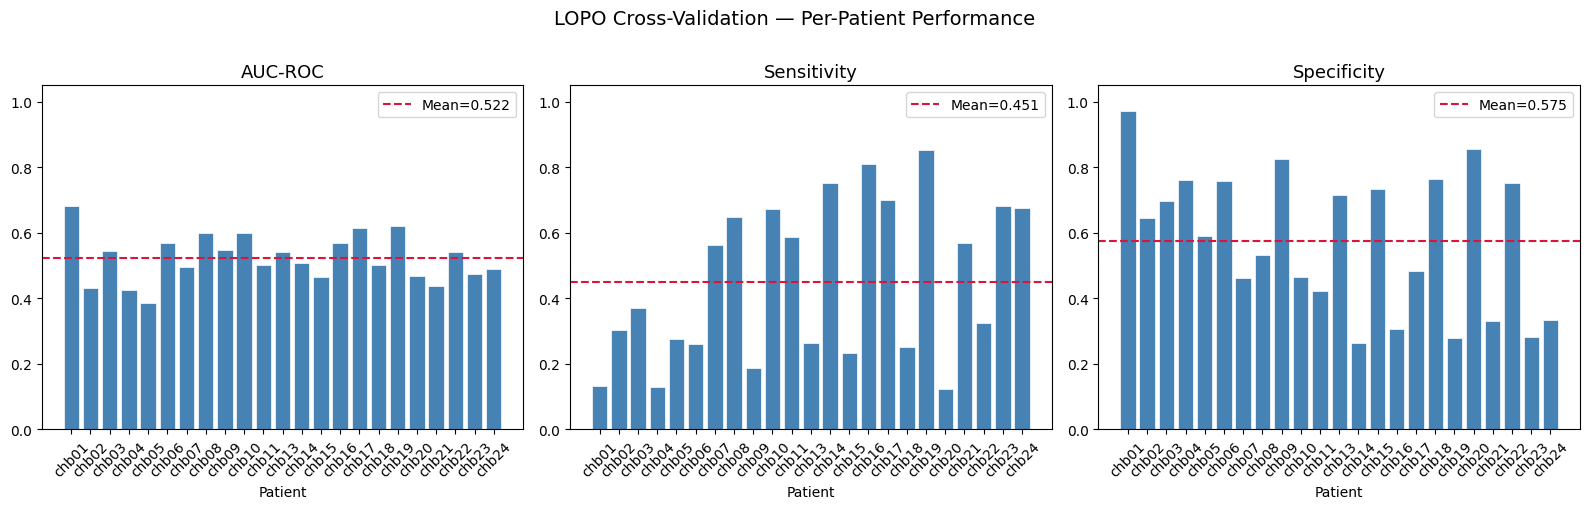

Figure saved.


In [8]:
# ── AUC distribution across patients ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ["auc", "sensitivity", "specificity"]
titles          = ["AUC-ROC", "Sensitivity", "Specificity"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals = lopo_df[metric].astype(float)
    ax.bar(lopo_df.index, vals, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.axhline(vals.mean(), color="crimson", linestyle="--", linewidth=1.5,
               label=f"Mean={vals.mean():.3f}")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Patient")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=10)

plt.suptitle("LOPO Cross-Validation — Per-Patient Performance", fontsize=14, y=1.01)
plt.tight_layout()
Path(RESULTS_DIR).mkdir(exist_ok=True)
plt.savefig(f"{RESULTS_DIR}/lopo_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

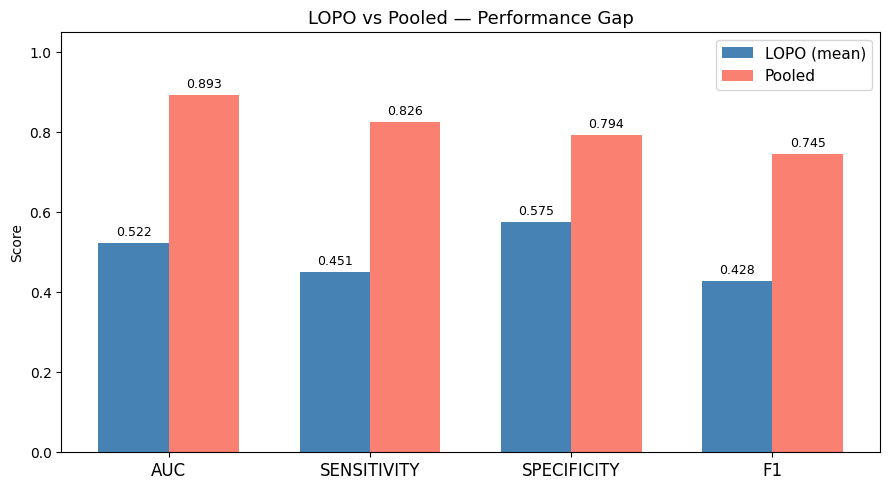

Figure saved.


In [9]:
# ── LOPO vs Pooled comparison bar chart ───────────────────────────────────────
metrics_compare = ["auc", "sensitivity", "specificity", "f1"]
lopo_means  = [lopo_df[m].astype(float).mean() for m in metrics_compare]
pooled_vals = [float(pooled_results[m]) for m in metrics_compare]

x     = np.arange(len(metrics_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, lopo_means,  width, label="LOPO (mean)",  color="steelblue")
b2 = ax.bar(x + width/2, pooled_vals, width, label="Pooled",       color="salmon")

ax.set_xticks(x)
ax.set_xticklabels([m.upper().replace("_", "-") for m in metrics_compare], fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("LOPO vs Pooled — Performance Gap", fontsize=13)
ax.legend(fontsize=11)

# Annotate bars
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/lopo_vs_pooled.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

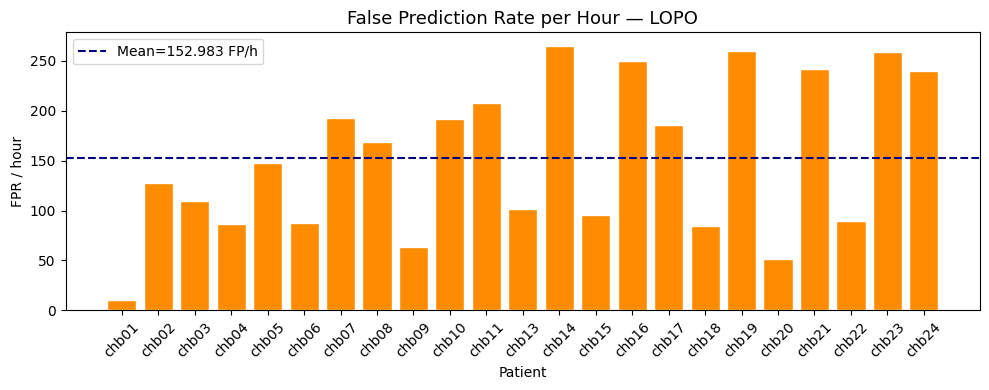

In [10]:
# ── FPR/h distribution ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fpr_vals = lopo_df["fpr_per_hour"].astype(float)
ax.bar(lopo_df.index, fpr_vals, color="darkorange", edgecolor="white")
ax.axhline(fpr_vals.mean(), color="navy", linestyle="--",
           label=f"Mean={fpr_vals.mean():.3f} FP/h")
ax.set_title("False Prediction Rate per Hour — LOPO", fontsize=13)
ax.set_xlabel("Patient")
ax.set_ylabel("FPR / hour")
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fpr_per_hour.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12 · Final Summary Table

In [11]:
display_cols = ["auc", "auc_pr", "sensitivity", "specificity",
                "precision", "f1", "balanced_accuracy", "fpr_per_hour"]

print("\n═══ LOPO Per-Patient Results ═══════════════════════════════════════")
print(lopo_df[display_cols].astype(float).round(4).to_string())

print("\n─── LOPO Aggregate ───────────────────────────────────────────────────")
agg = lopo_df[display_cols].astype(float).agg(["mean", "std"])
print(agg.round(4).to_string())

print("\n─── Pooled Baseline ──────────────────────────────────────────────────")
print(pd.DataFrame([pooled_results])[display_cols].round(4).to_string(index=False))


═══ LOPO Per-Patient Results ═══════════════════════════════════════
          auc  auc_pr  sensitivity  specificity  precision      f1  balanced_accuracy  fpr_per_hour
chb01  0.6828  0.7678       0.1318       0.9721     0.8864  0.2294             0.5519       10.0559
chb02  0.4309  0.4284       0.3041       0.6453     0.4369  0.3586             0.4747      127.7064
chb03  0.5431  0.6945       0.3716       0.6963     0.7174  0.4896             0.5339      109.3458
chb04  0.4245  0.1189       0.1284       0.7606     0.0844  0.1019             0.4445       86.1825
chb05  0.3846  0.5673       0.2748       0.5896     0.5422  0.3647             0.4322      147.7291
chb06  0.5687  0.1806       0.2613       0.7576     0.1709  0.2066             0.5094       87.2788
chb07  0.4963  0.1406       0.5640       0.4634     0.1583  0.2472             0.5137      193.1672
chb08  0.6009  0.6463       0.6491       0.5308     0.6571  0.6531             0.5900      168.8972
chb09  0.5481  0.2280       0.